# Sesión 5 — Modelado estructural del pórtico de concreto armado

## Aplicación portable: edificio didáctico de 2 pisos

Esta sesión consume la geometría del caso maestro y la biblioteca $M$–$\theta(P)$ de la sesión 3. Construye el mismo contrato estructural 3.4 que utiliza `PUSHOVER_PORTABLE`: nodos, GDL, elementos, brazos rígidos, diafragmas y rótulas concentradas.

## 1. Entorno y contratos previos

La sesión 4 es una verificación numérica; la biblioteca de la sesión 3 y el caso maestro son las entradas físicas para construir el modelo.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

def buscar_raiz(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    for carpeta in (inicio, *inicio.parents):
        if (carpeta/"temario.md").is_file() and (carpeta/"PUSHOVER_PORTABLE").is_dir():
            return carpeta
    raise FileNotFoundError("No se encontró la raíz del curso.")

RAIZ = buscar_raiz()
PORTABLE = RAIZ/"PUSHOVER_PORTABLE"
if str(PORTABLE) in sys.path:
    sys.path.remove(str(PORTABLE))
sys.path.insert(0, str(PORTABLE))
RUTA_MAESTRA = PORTABLE/"casos"/"edificio_2pisos.json"
RUTA_C03 = RAIZ/"sesion_03"/"resultados_portable_2pisos"/"contrato_sesion03_2pisos.json"

from ejecutar_pushover import cargar_entrada_maestra
from sesion_03.biblioteca_rotulas import leer_contrato_sesion03
from sesion_05 import contrato_portable
from sesion_05.contrato_portable import construir_contrato_sesion05, guardar_contrato_sesion05
from sesion_05.modelo_portico import ensamblar_rigidez_global

entrada, _, _ = cargar_entrada_maestra(RUTA_MAESTRA)
c03=leer_contrato_sesion03(RUTA_C03); biblioteca=c03["biblioteca_rotulas"]
ruta_c04=RAIZ/"sesion_04"/"resultados_portable_2pisos"/"contrato_sesion04_2pisos.json"
c04=json.loads(ruta_c04.read_text(encoding="utf-8"))
print("Módulo:",Path(contrato_portable.__file__).relative_to(RAIZ))
print("Entradas: S3 schema",c03["schema_version"],"; S4 schema",c04["schema_version"])
assert PORTABLE in Path(contrato_portable.__file__).resolve().parents

Módulo: PUSHOVER_PORTABLE\sesion_05\contrato_portable.py
Entradas: S3 schema 3.5 ; S4 schema 2.3


## 2. Idealización del edificio

Cada nodo posee $[u_x,u_y,\theta_z]$. Los dos pórticos resistentes en la dirección de análisis se representan coplanares y se enlazan en cada nivel mediante barras axiales muy rígidas que representan compatibilidad de diafragma. Los otros pórticos de la dirección perpendicular no se incluyen como elementos resistentes del modelo plano.

In [2]:
contrato_s5=construir_contrato_sesion05(entrada,biblioteca)
nodos={int(k):np.array(v,float) for k,v in contrato_s5["nodos"].items()}
print("Pórticos:",contrato_s5["geometria"]["ids_porticos"])
print("Nodos:",len(nodos),"Elementos:",len(contrato_s5["elementos"]),
      "Diafragmas:",len(contrato_s5["puntales"]),"Rótulas:",len(contrato_s5["rotulas"]))
print("Nodos de base:",contrato_s5["geometria"]["nodos_base"])
print("Nodos de control en techo:",contrato_s5["geometria"]["nodos_techo"])
assert len(contrato_s5["rotulas"])==2*len(contrato_s5["elementos"])

Pórticos: ['P1', 'P2']
Nodos: 12 Elementos: 12 Diafragmas: 2 Rótulas: 24
Nodos de base: [1, 2, 7, 8]
Nodos de control en techo: [5, 6, 11, 12]


## 3. Geometría, conectividad y brazos rígidos

Las rótulas se ubican en las caras de los nudos. La longitud flexible de cada elemento es $L_f=L-a_i-a_j$; por ello los offsets no son un detalle gráfico sino parte de la compatibilidad y la rigidez.

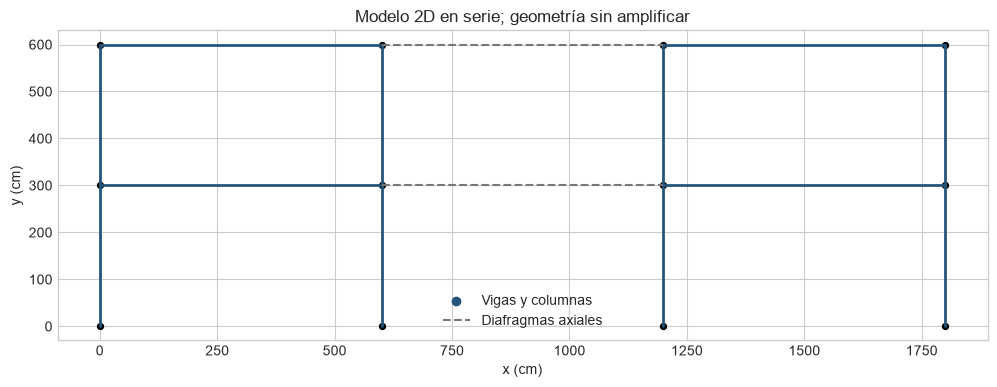

  E     tipo  sec    L eje     ai     aj       Lf
  1  columna   C1    300.0    0.0   27.5    272.5
  2  columna   C1    300.0    0.0   27.5    272.5
  3     viga   V1    600.0   30.0   30.0    540.0
  4  columna   C2    300.0   27.5   20.0    252.5
  5  columna   C2    300.0   27.5   20.0    252.5
  6     viga   V2    600.0   27.5   27.5    545.0


In [3]:
fig,ax=plt.subplots(figsize=(12,5))
for e in contrato_s5["elementos"]:
    xi,yi=nodos[int(e["i"])]; xj,yj=nodos[int(e["j"])]
    ax.plot([xi,xj],[yi,yj],color="#24557a",lw=2)
for p in contrato_s5["puntales"]:
    xi,yi=nodos[int(p["i"])]; xj,yj=nodos[int(p["j"])]
    ax.plot([xi,xj],[yi,yj],"--",color="#777777",lw=1.5)
for nid,(x,y) in nodos.items(): ax.scatter(x,y,s=18,color="black")
ax.scatter([],[],color="#24557a",label="Vigas y columnas")
ax.plot([],[],"--",color="#777777",label="Diafragmas axiales")
ax.set_aspect("equal"); ax.set(xlabel="x (cm)",ylabel="y (cm)",title="Modelo 2D en serie; geometría sin amplificar")
ax.legend(); plt.show()

print(f"{'E':>3} {'tipo':>8} {'sec':>4} {'L eje':>8} {'ai':>6} {'aj':>6} {'Lf':>8}")
for e in contrato_s5["elementos"][:6]:
    L=np.linalg.norm(nodos[int(e["j"])]-nodos[int(e["i"])])
    Lf=L-e["brazo_i_cm"]-e["brazo_j_cm"]
    print(f"{e['id']:3d} {e['tipo']:>8} {e['seccion_id']:>4} {L:8.1f} {e['brazo_i_cm']:6.1f} {e['brazo_j_cm']:6.1f} {Lf:8.1f}")
    assert Lf>0

## 4. Ensamblaje y estabilidad

Se ensambla la matriz de los elementos principales. Los diafragmas se verifican por separado en el solver de la sesión 6. Con los GDL de base restringidos, la submatriz libre debe tener rango completo.

In [4]:
K,_,gdl=ensamblar_rigidez_global(nodos,contrato_s5["elementos"])
restr=np.array(contrato_s5["restricciones_gdl"],int)
libres=np.setdiff1d(np.arange(K.shape[0]),restr)
Kff=K[np.ix_(libres,libres)]
print("K global:",K.shape,"simétrica:",np.allclose(K,K.T))
print("Rango Kff (sin diafragmas):",np.linalg.matrix_rank(Kff),"de",len(libres))
assert np.allclose(K,K.T) and np.linalg.matrix_rank(Kff)==len(libres)

K global: (36, 36) simétrica: True
Rango Kff (sin diafragmas): 24 de 24


## 5. Exportación del contrato S5

Este archivo será leído directamente por la sesión 6 para gravedad, calibración axial y pushover.

In [5]:
salida=RAIZ/"sesion_05"/"resultados_portable_2pisos"; salida.mkdir(parents=True,exist_ok=True)
ruta_c05=salida/"contrato_sesion05_2pisos.json"
guardar_contrato_sesion05(contrato_s5,ruta_c05)
releido=json.loads(ruta_c05.read_text(encoding="utf-8"))
assert releido["schema_version"]=="3.4" and releido["caso_id"]=="edificio_2pisos"
print("Guardado:",ruta_c05.relative_to(RAIZ),f"({ruta_c05.stat().st_size/1024:.1f} KiB)")

Guardado: sesion_05\resultados_portable_2pisos\contrato_sesion05_2pisos.json (39.0 KiB)


## 6. Cierre

El contrato 3.4 contiene la topología y las leyes iniciales a $P=0$. En la sesión 6 primero se resolverá gravedad y luego se interpolarán nuevamente $EI$ y $M$–$	heta$ para la carga axial real de cada columna antes de iniciar el empuje lateral.

---

# Parte B — Modelo estructural de `MI_EDIFICIO`

Se construye el contrato 3.4 con la geometría, asignaciones, diafragmas y rótulas del edificio personalizado. La sesión 6 leerá directamente este archivo.

In [6]:
EJECUTAR_MI_EDIFICIO = False
RUTA_MAESTRA_MI = PORTABLE / "casos" / "MI_EDIFICIO" / "entrada_maestra.json"

if not EJECUTAR_MI_EDIFICIO:
    print("Práctica MI_EDIFICIO desactivada. Actívala después de completar las sesiones 3 y 4.")
else:
    entrada_mi, _, _ = cargar_entrada_maestra(RUTA_MAESTRA_MI)
    caso_id_mi = str(entrada_mi["caso_id"]).strip()
    if "CAMBIAR" in caso_id_mi.upper():
        raise ValueError("Reemplaza MI_EDIFICIO_CAMBIAR por un caso_id propio.")
    BASE_MI = RAIZ / "resultados_curso_portable" / caso_id_mi
    RUTA_C03_MI = BASE_MI / "sesion_03" / "contrato_sesion03.json"
    if not RUTA_C03_MI.is_file():
        raise FileNotFoundError("Primero ejecuta la Parte B de la sesión 3: " + str(RUTA_C03_MI))
    c03_mi = leer_contrato_sesion03(RUTA_C03_MI)
    biblioteca_mi = c03_mi["biblioteca_rotulas"]
    contrato_s5_mi = construir_contrato_sesion05(entrada_mi, biblioteca_mi)
    salida_mi = BASE_MI / "sesion_05"
    RUTA_C05_MI = salida_mi / "contrato_sesion05.json"
    guardar_contrato_sesion05(contrato_s5_mi, RUTA_C05_MI)
    print("Caso:", caso_id_mi)
    print("Nodos:", len(contrato_s5_mi["nodos"]), "| elementos:", len(contrato_s5_mi["elementos"]),
          "| rótulas:", len(contrato_s5_mi["rotulas"]))
    print("Contrato guardado:", RUTA_C05_MI.relative_to(RAIZ))

Práctica MI_EDIFICIO desactivada. Actívala después de completar las sesiones 3 y 4.
